# 01_Exploratory Data Analysis

This notebook performs exploratory data analysis on the raw CRMLS listing and sold files before any cleaning or feature engineering. The goal is to understand the property type mix, summarize key residential sale patterns, inspect days on market and sale-to-list behavior, check for basic date inconsistencies, and compare county-level price patterns.

## Imports

In [22]:
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_functions.merge_crmls_dataset_unfiltered import merge_raw_crmls_data_unfiltered

Raw Data Loading

In [23]:
listing_df, sold_df = merge_raw_crmls_data_unfiltered(write_csv=False)
display(listing_df.head())

,source_file,file_period,sort_date,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName__dup2,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress__dup2
0,CRMLSListing202401.csv,202401,2024-01-01,1399990.0,1043760653,joe@porchlightsocal.com,2024-03-15,1270000.0,Joseph,Vahedi,...,2,,2.0,Vista Unified,92083,eXp Realty of Southern CA,252.0,9897.0,,123 Flores Lane
1,CRMLSListing202401.csv,202401,2024-01-01,8500.0,1052705926,champ@thereoco.com,2024-01-03,8500.0,Horace,Davenport,...,,False,,,90292,Keller Williams Larchmont,,5266.0,,952 PRINCETON Drive
2,CRMLSListing202401.csv,202401,2024-01-01,789900.0,1053093534,kiva@kivakendrick.com,2024-02-26,800000.0,Kiva,Kendrick,...,,False,2.0,Los Angeles Unified,90746,R & R Realty,,5070.0,,19922 Enslow Drive
3,CRMLSListing202401.csv,202401,2024-01-01,1050000.0,1054014526,sarah.pearce@cbrealty.com,,,Sarah,Pearce,...,,False,,,92262,,,10019.0,,2030 E Acacia Road
4,CRMLSListing202401.csv,202401,2024-01-01,1250000.0,1054022382,mricks@mypsrealtor.com,2024-02-26,1199000.0,Michael,Ricks,...,,False,2.0,,92262,BHG Desert Lifestyle Properties,,10454.0,,1695 E Buena Vista Drive


In [24]:
display(sold_df.head())

,source_file,file_period,sort_date,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
0,CRMLSSold202401.csv,202401,2024-01-01,Southland,Southland,,True,,,False,...,90048,0.0,6250.0,,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN
1,CRMLSSold202401.csv,202401,2024-01-01,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Wood,True,,,False,...,90038,,5874.0,,CRMLS,CRMLS_CL,NaN,NaN,NaN,NaN
2,CRMLSSold202401.csv,202401,2024-01-01,CaliforniaDesert,CaliforniaDesert,"Carpet,Tile",True,,,True,...,92270,1.0,13505.0,,CRMLS,CRMLS_CDAR,NaN,NaN,NaN,NaN
3,CRMLSSold202401.csv,202401,2024-01-01,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Vinyl,True,,,False,...,90069,,12934.0,,CRMLS,CRMLS_CL,NaN,NaN,NaN,NaN
4,CRMLSSold202401.csv,202401,2024-01-01,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,"Laminate,Tile",False,,,False,...,91406,0.0,4226.0,,CRMLS,CRMLS_CL,NaN,NaN,NaN,NaN


In [25]:
print("Listing shape:", listing_df.shape)
print("Sold shape:", sold_df.shape)

Listing shape: (852963, 87)
Sold shape: (591733, 87)


key numeric columns:

In [26]:
numeric_cols = [
    "ClosePrice",
    "ListPrice",
    "OriginalListPrice",
    "LivingArea",
    "LotSizeAcres",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "DaysOnMarket",
    "YearBuilt"
]

In [27]:
listing_df[numeric_cols].dtypes

ClosePrice               object
ListPrice                object
OriginalListPrice        object
LivingArea               object
LotSizeAcres             object
BedroomsTotal            object
BathroomsTotalInteger    object
DaysOnMarket             object
YearBuilt                object
dtype: object

In [28]:
sold_df[numeric_cols].dtypes

ClosePrice               object
ListPrice                object
OriginalListPrice        object
LivingArea               object
LotSizeAcres             object
BedroomsTotal            object
BathroomsTotalInteger    object
DaysOnMarket             object
YearBuilt                object
dtype: object

Convert numerical columns for both dataset

In [29]:
sold_df[numeric_cols] = sold_df[numeric_cols].apply(pd.to_numeric, errors="coerce")

listing_df[numeric_cols] = listing_df[numeric_cols].apply(pd.to_numeric, errors="coerce")

display(sold_df[numeric_cols].dtypes)

ClosePrice               float64
ListPrice                float64
OriginalListPrice        float64
LivingArea               float64
LotSizeAcres             float64
BedroomsTotal            float64
BathroomsTotalInteger    float64
DaysOnMarket               int64
YearBuilt                float64
dtype: object

Convert sold date columns

In [30]:
date_cols = [
    "CloseDate",
    "PurchaseContractDate",
    "ListingContractDate",
    "ContractStatusChangeDate"
]

In [31]:
for col in date_cols:
    if col in sold_df.columns:
        sold_df[col] = pd.to_datetime(sold_df[col], errors="coerce")

### 1. Residential vs other property type share for **listings**

In [32]:
listing_property_counts = listing_df["PropertyType"].value_counts(dropna=False)
listing_total = listing_property_counts.sum()

listing_residential_count = listing_property_counts.get("Residential", 0)
listing_other_count = listing_total - listing_residential_count

listing_property_share = pd.DataFrame({
    "group": ["Residential", "Other"],
    "count": [listing_residential_count, listing_other_count],
    "percent": [
        listing_residential_count / listing_total * 100,
        listing_other_count / listing_total * 100
    ]
})

display(listing_property_share)

,group,count,percent
0,Residential,540183,63.33018
1,Other,312780,36.66982


### 2. Residential vs other property type share for **sold**

In [33]:
sold_property_counts = sold_df["PropertyType"].value_counts(dropna=False)
sold_total = sold_property_counts.sum()

sold_residential_count = sold_property_counts.get("Residential", 0)
sold_other_count = sold_total - sold_residential_count

sold_property_share = pd.DataFrame({
    "group": ["Residential", "Other"],
    "count": [sold_residential_count, sold_other_count],
    "percent": [
        sold_residential_count / sold_total * 100,
        sold_other_count / sold_total * 100
    ]
})

display(sold_property_share)

,group,count,percent
0,Residential,397603,67.192974
1,Other,194130,32.807026


### 3. Create a Residential sold subset

In [34]:
sold_residential = sold_df[sold_df["PropertyType"] == "Residential"].copy()

print("Residential sold shape:", sold_residential.shape)
display(sold_residential[numeric_cols].dtypes)

Residential sold shape: (397603, 87)


ClosePrice               float64
ListPrice                float64
OriginalListPrice        float64
LivingArea               float64
LotSizeAcres             float64
BedroomsTotal            float64
BathroomsTotalInteger    float64
DaysOnMarket               int64
YearBuilt                float64
dtype: object

### 4. Median and average close prices

In [35]:
close_price_summary = pd.DataFrame({
    "metric": ["median_close_price", "average_close_price"],
    "value": [
        sold_residential["ClosePrice"].median(),
        sold_residential["ClosePrice"].mean()
    ]
})

display(close_price_summary)

,metric,value
0,median_close_price,8.200000e+05
1,average_close_price,1.185616e+06


### 5. Days on Market distribution

In [36]:
dom = sold_residential["DaysOnMarket"].dropna()

dom_summary = pd.DataFrame({
    "statistic": [
        "count", "mean", "median", "min",
        "p25", "p75", "p95", "p99", "max",
        "negative_count"
    ],
    "value": [
        dom.shape[0],
        dom.mean(),
        dom.median(),
        dom.min(),
        dom.quantile(0.25),
        dom.quantile(0.75),
        dom.quantile(0.95),
        dom.quantile(0.99),
        dom.max(),
        (dom < 0).sum()
    ]
})

display(dom_summary)

,statistic,value
0,count,397603.000000
1,mean,37.336788
2,median,19.000000
3,min,-288.000000
4,p25,8.000000
5,p75,48.000000
6,p95,131.000000
7,p99,229.000000
8,max,12430.000000
9,negative_count,46.000000


#### 5.1 Trimmed Days on Market histogram

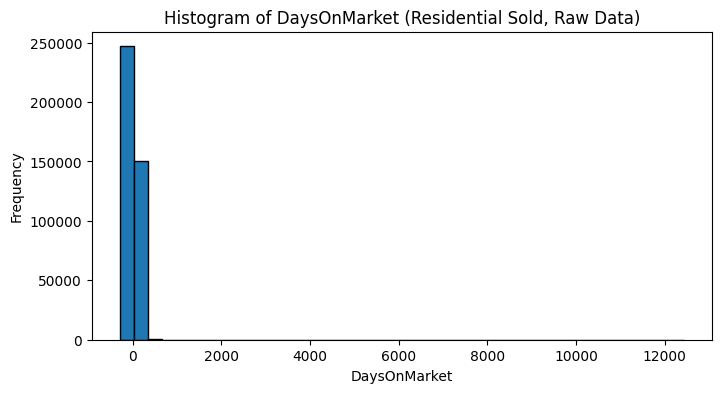

In [37]:
dom = sold_residential["DaysOnMarket"].dropna()

plt.figure(figsize=(8, 4))
plt.hist(dom, bins=40, edgecolor="black")
plt.title("Histogram of DaysOnMarket (Residential Sold, Raw Data)")
plt.xlabel("DaysOnMarket")
plt.ylabel("Frequency")
plt.show()

### 6. Percentage sold above vs below list price

In [38]:
prices = sold_residential.dropna(subset=["ClosePrice", "ListPrice"])
diff = prices["ClosePrice"] - prices["ListPrice"]

sale_to_list_summary = pd.DataFrame([
    {"group": "Above list", "count": (diff > 0).sum()},
    {"group": "Below list", "count": (diff < 0).sum()},
    {"group": "At list",    "count": (diff == 0).sum()}
])

sale_to_list_summary["percent"] = (sale_to_list_summary["count"] / len(diff)) * 100

display(sale_to_list_summary)

,group,count,percent
0,Above list,159483,40.111318
1,Below list,169158,42.544662
2,At list,68960,17.344021


### 7. Date consistency checks

In [39]:
date_issue_summary = pd.DataFrame({
    "check": [
        "CloseDate before ListingContractDate",
        "CloseDate before PurchaseContractDate",
        "PurchaseContractDate before ListingContractDate"
    ],
    "issue_count": [
        (sold_residential["CloseDate"] < sold_residential["ListingContractDate"]).sum(),
        (sold_residential["CloseDate"] < sold_residential["PurchaseContractDate"]).sum(),
        (sold_residential["PurchaseContractDate"] < sold_residential["ListingContractDate"]).sum()
    ]
})

display(date_issue_summary)

,check,issue_count
0,CloseDate before ListingContractDate,58
1,CloseDate before PurchaseContractDate,240
2,PurchaseContractDate before ListingContractDate,261


### 8. Counties with the highest median prices

In [40]:
county_price_summary = (
    sold_residential.groupby("CountyOrParish")["ClosePrice"]
    .describe()[['50%', 'mean', 'count']].reset_index()
    .rename(columns={"50%": "median_close_price"})
)

display(county_price_summary.nlargest(15, "median_close_price"))

,CountyOrParish,median_close_price,mean,count
8,Del Norte,2485000.0,2.485000e+06,1.0
33,Other County,2462500.0,9.504750e+07,4.0
45,San Mateo,1700000.0,2.195950e+06,7004.0
47,Santa Clara,1600000.0,1.920275e+06,17862.0
48,Santa Cruz,1200000.0,1.347115e+06,2902.0
42,San Francisco,1180000.0,1.305188e+06,921.0
31,Orange,1175000.0,1.532290e+06,44733.0
22,Marin,1170000.0,1.366315e+06,139.0
0,Alameda,1135000.0,1.309826e+06,18752.0
1,Alpine,1100000.0,1.100000e+06,1.0


#### 8.1 Counties with at least 50 sales

In [41]:
county_price_summary_50 = county_price_summary[
    county_price_summary["count"] >= 50
].sort_values("median_close_price", ascending=False).reset_index(drop=True)

display(county_price_summary_50.head(10))

,CountyOrParish,median_close_price,mean,count
0,San Mateo,1700000.0,2.195950e+06,7004.0
1,Santa Clara,1600000.0,1.920275e+06,17862.0
2,Santa Cruz,1200000.0,1.347115e+06,2902.0
3,San Francisco,1180000.0,1.305188e+06,921.0
4,Orange,1175000.0,1.532290e+06,44733.0
5,Marin,1170000.0,1.366315e+06,139.0
6,Alameda,1135000.0,1.309826e+06,18752.0
7,Monterey,907000.0,1.404036e+06,3844.0
8,Los Angeles,900000.0,1.322352e+06,98836.0
9,San Diego,895000.0,1.435684e+06,48974.0


## Conclusion:

In [42]:
print("Residential share in listings:",
      round(listing_residential_count / listing_total * 100, 2), "%")

print("Residential share in sold:",
      round(sold_residential_count / sold_total * 100, 2), "%")

print("Median residential close price:",
      round(sold_residential["ClosePrice"].median(), 2))

print("Average residential close price:",
      round(sold_residential["ClosePrice"].mean(), 2))

print("Median residential DaysOnMarket:",
      round(dom.median(), 2))

print("Average residential DaysOnMarket:",
      round(dom.mean(), 2))

Residential share in listings: 63.33 %
Residential share in sold: 67.19 %
Median residential close price: 820000.0
Average residential close price: 1185616.36
Median residential DaysOnMarket: 19.0
Average residential DaysOnMarket: 37.34


- Residential vs. other property type share: Residential properties make up 63.33% of listings and 67.19% of sold properties, so they are the dominant property type in both datasets. This means other property types account for 36.67% of listings and 32.81% of sold properties.

- Median and average close prices: For sold residential homes, the median close price is $820,000 and the average close price is $1,185,616.36. Since the average is much higher than the median, the close price distribution appears to be right-skewed.

- Days on Market distribution: For sold residential homes, the median Days on Market is 19 days and the average is 37.34 days. This suggests that most homes sell fairly quickly, but some homes stay on the market much longer, creating a right-skewed distribution.

- Percentage of homes sold above vs. below list price: Among sold residential homes, 40.11% sold above list price, 42.54% sold below list price, and 17.34% sold exactly at list price. Overall, slightly more homes sold below list than above list.

- Apparent date consistency issues: There are some records with inconsistent dates, including 58 cases where the close date is before the listing date, 240 cases where the close date is before the purchase contract date, and 261 cases where the purchase contract date is before the listing date.

- Counties with the highest median prices: The counties with the highest reported median close prices include San Mateo, Santa Clara, Santa Cruz, San Francisco, and Orange. However, some counties with the very highest medians have very small sales counts, so those results should be interpreted carefully.